# BÁO CÁO DỰ ÁN: Question Difficulty and Student Ability Discrimination 
## Học phần: Khoa Học Dữ Liệu

### 1.Giới thiệu mục tiêu
Dự án tập trung vào việc phân tích dữ liệu tương tác từ nền tảng học tập **Riiid**.
Mục tiêu chính là ứng dụng mô hình toán học để xác định độ khó của từng câu hỏi, từ đó đưa ra các đánh giá khách quan về chất lượng bộ đề thi.

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# đọc dữ liệu
train = pd.read_csv('data/sample_train.csv')
questions = pd.read_csv('data/questions.csv')
lectures = pd.read_csv('data/lectures.csv')

print("Đã đọc thành công 3 file dữ liệu.")

Đã đọc thành công 3 file dữ liệu.


### 2. Mô tả dữ liệu (Data Description)
Dữ liệu bao gồm 3 file CSV. Trong đó:
- **sample_train.csv**: tương tác của học sinh (100.000 dòng).
  + timestamp: Thời gian (mili giây) từ lúc học sinh bắt đầu tương tác lần đầu.
  + <span style="color:red">user_id</span>: Mã định danh của học sinh.
  + <span style="color:red">content_id</span>: Mã định danh của câu hỏi hoặc bài giảng.
  + content_type_id: 0 nếu là câu hỏi, 1 nếu là bài giảng.
  + <span style="color:red">answered_correctly</span>: Kết quả: 1 là đúng, 0 là sai.
- **questions.csv**: thông tin chi tiết về các câu hỏi (id).
  + question_id: tương tự content_id trong file train.
  + bundle_id: Mã nhóm các câu hỏi dùng chung một đoạn văn/đoạn hội thoại.
  + correct_answer: Đáp án đúng của câu hỏi đó.
  + part: Phần thi
  + tags: Các mã kỹ năng
- **lectures.csv**: Thông tin các bài giảng (id, tag, part, type)
  + lecture_id: Mã bài giảng 
  + part: Bài giảng đó thuộc phần kiến thức nào.
  + tag: Chủ đề của bài giảng.
  + type_of: Loại bài giảng

### 3. Tiền xử lý dữ liệu
Để đảm bảo tính chính xác cho mô hình IRT, thực hiện:
- Loại bỏ các dòng tương tác là bài giảng (`content_type_id == 1`)=> chỉ giữ lại các dòng là câu hỏi.
- Giữ lại các dòng làm bài trắc nghiệm có kết quả hợp lệ ( `answered_correctly= 0 or answered_correctly= 1` ).

In [16]:
# Lọc dữ liệu: chỉ lấy câu hỏi, tạo bản sao của train.
df_clean = train[train['content_type_id'] == 0].copy()
df_clean = df_clean[(df_clean['answered_correctly']) == 0 | (df_clean['answered_correctly'] == 1)]

print(f"Kích thước dữ liệu sau khi làm sạch: {df_clean.shape}")
print(f"Số lượng học sinh trong mẫu: {df_clean['user_id'].nunique()}")

Kích thước dữ liệu sau khi làm sạch: (99563, 10)
Số lượng học sinh trong mẫu: 55568


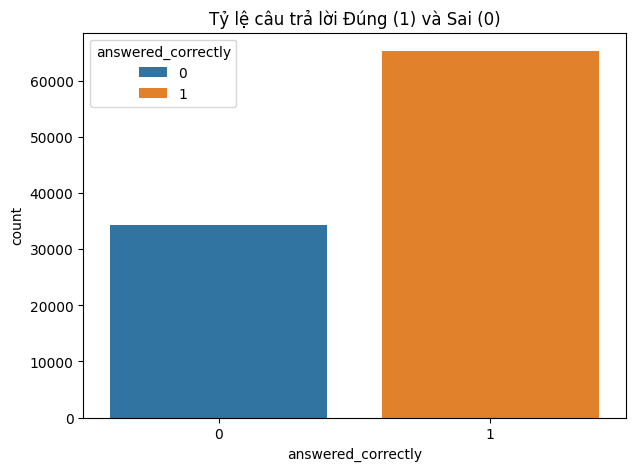

Tỷ lệ trả lời đúng trung bình của mẫu: 65.60%


In [ ]:
# Biểu đồ tỷ lệ Đúng/Sai 
plt.figure(figsize = (7, 5)) #plt.figure: Khởi tạo một khung hình để vẽ với chiều ngang 7 đơn vị chiều dọc 5 đơn vị
sns.countplot(x = 'answered_correctly', data = df_clean, hue = 'answered_correctly') #hue='answered_correctly': Tô màu khác nhau dựa trên giá trị (đúng/sai).
plt.title('Tỷ lệ câu trả lời Đúng (1) và Sai (0)')
plt.show()

# Tính tỷ lệ đúng trung bình
mean_correct = df_clean['answered_correctly'].sum() / len(df_clean)
print(f"Tỷ lệ trả lời đúng trung bình của mẫu: {mean_correct:.2%}")


**Nhận xét:** Dựa vào biểu đồ, ta thấy tỷ lệ trả lời đúng chiếm khoảng 65.60%. Điều này cho thấy tập câu hỏi mẫu có độ khó vừa phải, phù hợp để triển khai các bước tính toán tiếp theo.

### 4. Merge dữ liệu
Tiến hành gộp (merge) bảng dữ liệu df_clean với bảng câu hỏi (`questions.csv`) để lấy thông tin về phần thi (Part) của từng câu hỏi.

In [18]:

df_merged = df_clean.merge(questions[['question_id', 'part']], 
                           left_on = 'content_id', 
                           right_on = 'question_id', 
                           how = 'left')

# Hiển thị 5 dòng đầu tiên 
df_merged.head()

,row_id,timestamp,user_id,content_id,content_type_id,task_container_id,user_answer,answered_correctly,prior_question_elapsed_time,prior_question_had_explanation,question_id,part
0,419,3159614374,12741,9133,0,43,0,0,22000.0,True,9133,5
1,610,4464214869,12741,7748,0,103,1,1,32750.0,True,7748,7
2,712,14570276178,13134,1315,0,80,1,0,20000.0,True,1315,2
3,1485,16570832784,13134,11976,0,709,1,1,19000.0,True,11976,2
4,1824,17571812750,13134,11968,0,1004,3,1,16000.0,True,11968,2


### 5. Trực quan hóa tỷ lệ trả lời đúng theo từng phần thi (Part 1 - Part 7).

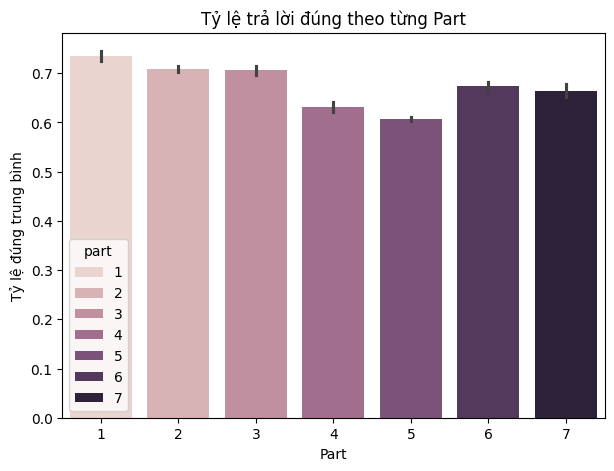

In [19]:
# Vẽ biểu đồ tỷ lệ đúng theo từng Part 
plt.figure(figsize = (7, 5))
sns.barplot(
    x = 'part', 
    y = 'answered_correctly', 
    data = df_merged, 
    hue = 'part' # Gán part vào hue để tô màu theo từng cột
)
plt.title('Tỷ lệ trả lời đúng theo từng Part')
plt.ylabel('Tỷ lệ đúng trung bình')
plt.xlabel('Part')
plt.show()

In [ ]:
# Tính tỷ lệ trả lời đúng và tổng số câu hỏi đã làm cho từng Part
part_stats = df_merged.groupby('part')['answered_correctly'].agg(['mean', 'count']).reset_index()

# Đổi tên cột
part_stats.rename(columns={'mean': 'Tỷ lệ đúng', 'count': 'Tổng số lượt làm'}, inplace=True)

# Định dạng cột tỷ lệ sang dạng % (ví dụ: 0.732 -> 73.2%)
part_stats['Tỷ lệ đúng'] = (part_stats['Tỷ lệ đúng'] * 100).round(2).astype(str) + '%'

part_stats

,part,Tỷ lệ đúng,Tổng số lượt làm
0,1,73.48%,7603
1,2,70.9%,18672
2,3,70.55%,8689
3,4,63.07%,8026
4,5,60.66%,41205
5,6,67.33%,10583
6,7,66.37%,4785


**Nhận xét phân tích tỷ lệ trả lời đúng theo từng Part:**

Dựa vào biểu đồ trực quan hóa, ta có thể thấy rõ sự phân hóa về độ khó giữa các phần thi (Part) trong bộ dữ liệu:

* **Nhóm câu hỏi "Dễ" (Part 1, 2 và 3):** Tỷ lệ trả lời đúng đạt mức cao nhất, dao động vượt ngưỡng 70% (đỉnh điểm là Part 1 với khoảng 73%). Điều này cho thấy học sinh dễ dàng ghi điểm ở các phần này.
* **Nhóm câu hỏi "Khó nhất" (Part 5):** Cột Part 5 chạm đáy với tỷ lệ đúng thấp nhất (chỉ khoảng 60%). Đây chính là mà đa số học sinh, đòi hỏi nền tảng kiến thức vững chắc hơn.
* **Nhóm câu hỏi "Phân hóa trung bình" (Part 4, 6 và 7):** Tỷ lệ đúng duy trì ở mức trung bình khá (63% - 68%), đóng vai trò phân loại học sinh ở mức độ vừa phải.

In [21]:

# Chữ 'r' ở trước ngoặc kép giúp Python không bị lỗi với các dấu gạch chéo của Windows
save_dir = r"D:\Question_Difficulty_and_Student_Ability_Discrimination\data"

# 2. Tạo đường dẫn đầy đủ cho 2 file
path_clean = save_dir + r"\train_cleaned.csv"
path_merged = save_dir + r"\train_merged_with_parts.csv"

df_clean.to_csv(path_clean, index=False)
df_merged.to_csv(path_merged, index=False)

print(f"Hoàn tất! Đã lưu file csv với link:\n{save_dir}")

Hoàn tất! Đã lưu file csv với link:
D:\Question_Difficulty_and_Student_Ability_Discrimination\data
